<a href="https://colab.research.google.com/github/specM7/DSGP_Group_33_Brain_Tumor_Predictor/blob/glioblastoma-Vidu-2425444/Tumour-Mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting!")


Done extracting!


In [ ]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


root = "/content/extracted"
train_dir = os.path.join(root, "Training")
test_dir  = os.path.join(root, "Testing")

img_size   = 224
batch_size = 16
epochs     = 12
lr         = 1e-4
seed       = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

def crop_brain(img: Image.Image) -> Image.Image:
    """Simple brain crop using threshold + largest contour bounding box."""
    img_np = np.array(img)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return img
    cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)
    cropped = img_np[y:y+h, x:x+w]
    return Image.fromarray(cropped)


train_transform = transforms.Compose([
    transforms.Lambda(lambda im: crop_brain(im.convert("RGB"))),
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


test_transform = transforms.Compose([
    transforms.Lambda(lambda im: crop_brain(im.convert("RGB"))),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_set = datasets.ImageFolder(train_dir, transform=train_transform)
test_set  = datasets.ImageFolder(test_dir,  transform=test_transform)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_set.classes
num_classes = len(class_names)
print("Classes:", class_names)


model = models.resnet18(pretrained=True)


for p in model.parameters():
    p.requires_grad = False


for p in model.layer3.parameters():
    p.requires_grad = True
for p in model.layer4.parameters():
    p.requires_grad = True


model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

def train_one_epoch():
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def evaluate():
    model.eval()
    correct = 0
    total = 0
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return correct / total

for epoch in range(epochs):
    loss, acc = train_one_epoch()
    val_acc = evaluate()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Train Acc: {acc:.4f} | Test Acc: {val_acc:.4f}")

torch.save(model.state_dict(), "tumor_model_resnet18.pth")
print("Model saved: tumor_model_resnet18.pth")


model.eval()
target_layers = [model.layer4[-1]]

cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers,
    use_cuda=torch.cuda.is_available()
)

def apply_gradcam_pp(img_path, mask_threshold=0.6):
    """
    Produces:
    - Original (cropped+resized)
    - Grad-CAM++ heatmap
    - Overlay
    - Rough binary mask (thresholded heatmap)
    """
    pil = Image.open(img_path).convert("RGB")
    pil = crop_brain(pil)
    original = pil.resize((img_size, img_size))

    x = test_transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)

    # Predict class
    with torch.no_grad():
        outputs = model(x)
        class_idx = outputs.argmax(1).item()

    # Grad-CAM++ heatmap for predicted class
    grayscale_cam = cam(
        input_tensor=x,
        targets=[ClassifierOutputTarget(class_idx)]
    )[0]  # (H,W) in [0,1]

    # Overlay on image
    original_np = np.array(original).astype(np.float32) / 255.0
    visualization = show_cam_on_image(original_np, grayscale_cam, use_rgb=True)

    # Rough mask
    mask = (grayscale_cam > mask_threshold).astype(np.uint8)

    # Plot
    plt.figure(figsize=(14,4))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(original_np)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Grad-CAM++")
    plt.imshow(grayscale_cam, cmap="jet")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Overlay")
    plt.imshow(visualization)
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title(f"Mask (>{mask_threshold})")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.suptitle(f"Predicted: {class_names[class_idx]}")
    plt.show()

some_class = random.choice(class_names)
folder = os.path.join(test_dir, some_class)
example_img = os.path.join(folder, random.choice(os.listdir(folder)))

print("Running Grad-CAM++ on:", example_img)
apply_gradcam_pp(example_img, mask_threshold=0.6)


Using: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/12 | Loss: 0.5699 | Train Acc: 0.9000 | Test Acc: 0.9527
Epoch 2/12 | Loss: 0.4534 | Train Acc: 0.9657 | Test Acc: 0.9840
Epoch 3/12 | Loss: 0.4267 | Train Acc: 0.9753 | Test Acc: 0.9847
Epoch 4/12 | Loss: 0.4076 | Train Acc: 0.9839 | Test Acc: 0.9886
Epoch 5/12 | Loss: 0.3898 | Train Acc: 0.9907 | Test Acc: 0.9916
Epoch 6/12 | Loss: 0.3830 | Train Acc: 0.9926 | Test Acc: 0.9847
Epoch 7/12 | Loss: 0.3801 | Train Acc: 0.9942 | Test Acc: 0.9931
Epoch 8/12 | Loss: 0.3759 | Train Acc: 0.9946 | Test Acc: 0.9947
Epoch 9/12 | Loss: 0.3766 | Train Acc: 0.9932 | Test Acc: 0.9947
Epoch 10/12 | Loss: 0.3715 | Train Acc: 0.9951 | Test Acc: 0.9947
Epoch 11/12 | Loss: 0.3695 | Train Acc: 0.9960 | Test Acc: 0.9870


Exception ignored in: <function BaseCAM.__del__ at 0x7edcb2e5ff60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_grad_cam/base_cam.py", line 212, in __del__
    self.activations_and_grads.release()
    ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'GradCAMPlusPlus' object has no attribute 'activations_and_grads'


Epoch 12/12 | Loss: 0.3681 | Train Acc: 0.9956 | Test Acc: 0.9893
Model saved: tumor_model_resnet18.pth


TypeError: GradCAMPlusPlus.__init__() got an unexpected keyword argument 'use_cuda'

In [ ]:
pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 86.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=2b0afac0a3f31b7d0b0214bbc251bf130601d2d96d072fcb2414b77012ab006a
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


Running Grad-CAM++ on: /content/extracted/Testing/meningioma/Te-me_0240.jpg


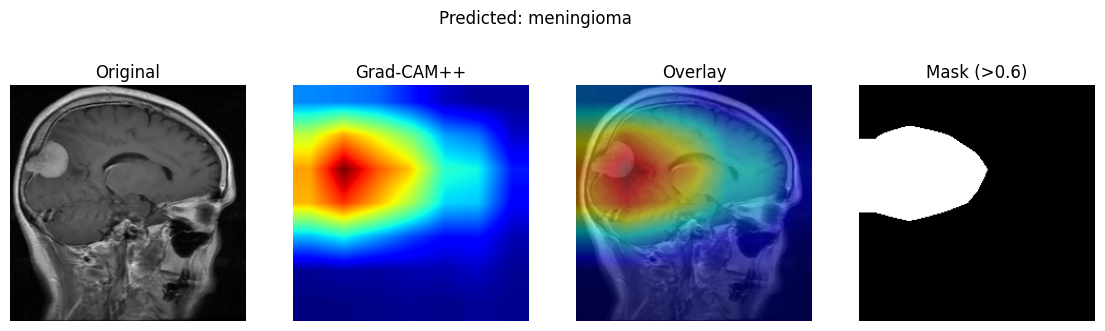

In [ ]:

# ========================
# GRAD-CAM++ SETUP
# ========================
model.eval()
target_layers = [model.layer4[-1]]

cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)



# ========================
# APPLY GRAD-CAM++
# ========================
def apply_gradcam_pp(img_path, mask_threshold=0.6):
    """
    Produces:
    - Original (cropped+resized)
    - Grad-CAM++ heatmap
    - Overlay
    - Rough binary mask (thresholded heatmap)
    """
    pil = Image.open(img_path).convert("RGB")
    pil = crop_brain(pil)
    original = pil.resize((img_size, img_size))

    x = test_transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)

    # Predict class
    with torch.no_grad():
        outputs = model(x)
        class_idx = outputs.argmax(1).item()

    # Grad-CAM++ heatmap for predicted class
    grayscale_cam = cam(
        input_tensor=x,
        targets=[ClassifierOutputTarget(class_idx)]
    )[0]  # (H,W) in [0,1]

    # Overlay on image
    original_np = np.array(original).astype(np.float32) / 255.0
    visualization = show_cam_on_image(original_np, grayscale_cam, use_rgb=True)

    # Rough mask
    mask = (grayscale_cam > mask_threshold).astype(np.uint8)

    # Plot
    plt.figure(figsize=(14,4))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(original_np)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Grad-CAM++")
    plt.imshow(grayscale_cam, cmap="jet")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Overlay")
    plt.imshow(visualization)
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title(f"Mask (>{mask_threshold})")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.suptitle(f"Predicted: {class_names[class_idx]}")
    plt.show()


# ========================
# TEST ONE IMAGE
# ========================
# Pick a random image from test folder
some_class = random.choice(class_names)
folder = os.path.join(test_dir, some_class)
example_img = os.path.join(folder, random.choice(os.listdir(folder)))

print("Running Grad-CAM++ on:", example_img)
apply_gradcam_pp(example_img, mask_threshold=0.6)